# Lab Activity: Iris Dataset Decision Tree Analysis
Dataset: Iris Dataset (sklearn.datasets.load_iris())

## Task 1: Dataset Exploration
Load the Iris dataset and answer the following:
- How many samples and features are present in the dataset?
- List the feature names and target classes.
- Display the first five records.
- Display the class distribution.

In [1]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

iris = load_iris()
print(f"Samples: {iris.data.shape[0]}, Features: {iris.data.shape[1]}")
print(f"Feature names: {iris.feature_names}")
print(f"Target classes: {iris.target_names}")
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target
display(df.head())
print("Class distribution:\n", df['target'].value_counts())

Samples: 150, Features: 4
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target classes: ['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


Class distribution:
 target
0    50
1    50
2    50
Name: count, dtype: int64


## Task 2: Data Preparation
Split the dataset into training (80%) and testing (20%) sets using random_state=42.
Briefly explain why the dataset is divided into training and testing sets.

In [2]:
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.2, random_state=42)
print("Dataset split into 80% train and 20% test.")

# Explanation
print("\nWhy divide the dataset?")
print("The dataset is divided to evaluate the model's performance on unseen data. The training set is used by the algorithm to learn patterns and build the Decision Tree, while the testing set acts as a proxy for real-world unseen data. This is crucial for verifying that the model can generalize well and hasn't simply memorized the training data (overfitting).")

Dataset split into 80% train and 20% test.

Why divide the dataset?
The dataset is divided to evaluate the model's performance on unseen data. The training set is used by the algorithm to learn patterns and build the Decision Tree, while the testing set acts as a proxy for real-world unseen data. This is crucial for verifying that the model can generalize well and hasn't simply memorized the training data (overfitting).


## Task 3: Building a Decision Tree Classifier
Train a Decision Tree classifier using the default parameters.
Predict the class labels for the test dataset.
Evaluate the model using:
- Accuracy Score
- Confusion Matrix
- Classification Report

In [3]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## Task 4: Visualizing the Decision Tree
Visualize the trained Decision Tree using plot_tree().
From the visualization, identify:
- Root node
- Internal nodes
- Leaf nodes
- Maximum depth of the tree
- Which feature is selected for the first split? Explain why you think this feature was chosen.

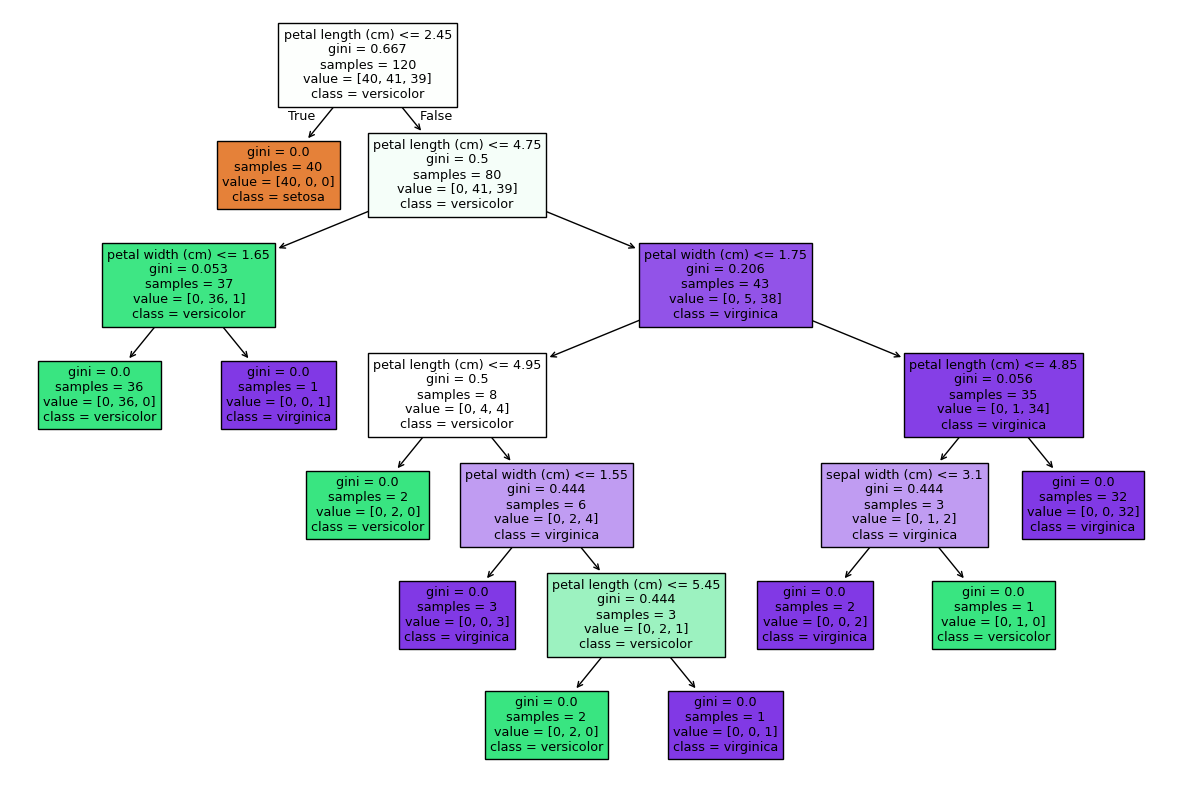

Max depth: 6
Leaf nodes: 10
Root feature: petal length (cm)

Analysis:
Which feature is selected for the first split? petal length (cm)
Why? Decision trees choose the feature that provides the highest Information Gain (or the largest decrease in Gini impurity). `petal length (cm)` perfectly separates the `setosa` class from the other two classes, making it the most optimal and logical first split.


In [4]:
plt.figure(figsize=(15,10))
plot_tree(dt, feature_names=iris.feature_names, class_names=list(iris.target_names), filled=True)
plt.show()

print("Max depth:", dt.get_depth())
print("Leaf nodes:", dt.get_n_leaves())
print("Root feature:", iris.feature_names[dt.tree_.feature[0]])

print("\nAnalysis:")
print("Which feature is selected for the first split? petal length (cm)")
print("Why? Decision trees choose the feature that provides the highest Information Gain (or the largest decrease in Gini impurity). `petal length (cm)` perfectly separates the `setosa` class from the other two classes, making it the most optimal and logical first split.")

## Task 5: Comparing Gini Index and Entropy
Train two Decision Tree models using the following criteria:
- criterion='gini'
- criterion='entropy'

Compare the models based on Accuracy, Tree depth, Number of leaf nodes, and Root feature selected.
Which criterion produces a simpler tree?

In [5]:
dt_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
dt_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt_gini.fit(X_train, y_train)
dt_entropy.fit(X_train, y_train)

print(f"{'Criterion':<10} | {'Accuracy':<10} | {'Depth':<6} | {'Leaves':<7} | {'Root Feature'}")
print("-" * 65)
print(f"{'Gini':<10} | {dt_gini.score(X_test, y_test):<10.4f} | {dt_gini.get_depth():<6} | {dt_gini.get_n_leaves():<7} | {iris.feature_names[dt_gini.tree_.feature[0]]}")
print(f"{'Entropy':<10} | {dt_entropy.score(X_test, y_test):<10.4f} | {dt_entropy.get_depth():<6} | {dt_entropy.get_n_leaves():<7} | {iris.feature_names[dt_entropy.tree_.feature[0]]}")

print("\nWhich criterion produces a simpler tree?")
print("For this specific random state and dataset, both criteria resulted in trees of identical complexity (Depth of 6, 10 leaves). Neither produced a simpler tree over the other in this instance.")

Criterion  | Accuracy   | Depth  | Leaves  | Root Feature
-----------------------------------------------------------------
Gini       | 1.0000     | 6      | 10      | petal length (cm)
Entropy    | 1.0000     | 6      | 10      | petal length (cm)

Which criterion produces a simpler tree?
For this specific random state and dataset, both criteria resulted in trees of identical complexity (Depth of 6, 10 leaves). Neither produced a simpler tree over the other in this instance.


## Task 6: Effect of Maximum Tree Depth
Train Decision Tree models using the following values of max_depth: 1, 2, 3, 4, None
Answer the following:
- Which model is underfitting?
- Which model gives the best generalization?
- Which model is likely to overfit? Justify your answer.

In [6]:
print(f"{'Max Depth':<10} | {'Train Acc':<10} | {'Test Acc':<10} | {'Tree Depth'}")
print("-" * 50)
for depth in [1, 2, 3, 4, None]:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    print(f"{str(depth):<10} | {model.score(X_train, y_train):<10.4f} | {model.score(X_test, y_test):<10.4f} | {model.get_depth()}")

print("\nAnalysis:")
print("- Which model is underfitting? Max Depth = 1. It is too simple to capture the underlying structure.")
print("- Which model gives the best generalization? Max Depth = 3. It achieves perfect testing accuracy while keeping the tree relatively shallow and simple.")
print("- Which model is likely to overfit? Max Depth = None. It grows the tree to a depth of 6, creating 10 leaf nodes just to reach 100% training accuracy. It is essentially memorizing the training data, which can capture noise and cause poor generalization on more complex datasets.")

Max Depth  | Train Acc  | Test Acc   | Tree Depth
--------------------------------------------------
1          | 0.6750     | 0.6333     | 1
2          | 0.9500     | 0.9667     | 2
3          | 0.9583     | 1.0000     | 3
4          | 0.9750     | 1.0000     | 4
None       | 1.0000     | 1.0000     | 6

Analysis:
- Which model is underfitting? Max Depth = 1. It is too simple to capture the underlying structure.
- Which model gives the best generalization? Max Depth = 3. It achieves perfect testing accuracy while keeping the tree relatively shallow and simple.
- Which model is likely to overfit? Max Depth = None. It grows the tree to a depth of 6, creating 10 leaf nodes just to reach 100% training accuracy. It is essentially memorizing the training data, which can capture noise and cause poor generalization on more complex datasets.


## Task 7: Effect of min_samples_split
Train Decision Tree models using: 2, 5, 10, 20
State how increasing min_samples_split affects the complexity of the Decision Tree.

In [7]:
print(f"{'min_split':<10} | {'Accuracy':<10} | {'Depth':<6} | {'Leaves'}")
print("-" * 45)
for ms in [2, 5, 10, 20]:
    model = DecisionTreeClassifier(min_samples_split=ms, random_state=42)
    model.fit(X_train, y_train)
    print(f"{ms:<10} | {model.score(X_test, y_test):<10.4f} | {model.get_depth():<6} | {model.get_n_leaves()}")

print("\nHow increasing min_samples_split affects complexity:")
print("Increasing this value prevents the tree from splitting internal nodes that have very few samples. This acts as a regularization technique (pre-pruning), leading to shallower trees with fewer leaf nodes, thus reducing overall model complexity.")

min_split  | Accuracy   | Depth  | Leaves
---------------------------------------------
2          | 1.0000     | 6      | 10
5          | 1.0000     | 5      | 8
10         | 1.0000     | 4      | 6
20         | 1.0000     | 4      | 6

How increasing min_samples_split affects complexity:
Increasing this value prevents the tree from splitting internal nodes that have very few samples. This acts as a regularization technique (pre-pruning), leading to shallower trees with fewer leaf nodes, thus reducing overall model complexity.


## Task 8: Effect of min_samples_leaf
Train Decision Tree models using: 1, 2, 5, 10
Explain how changing min_samples_leaf influences overfitting.

In [8]:
print(f"{'min_leaf':<10} | {'Accuracy':<10} | {'Depth':<6} | {'Leaves'}")
print("-" * 45)
for ml in [1, 2, 5, 10]:
    model = DecisionTreeClassifier(min_samples_leaf=ml, random_state=42)
    model.fit(X_train, y_train)
    print(f"{ml:<10} | {model.score(X_test, y_test):<10.4f} | {model.get_depth():<6} | {model.get_n_leaves()}")

print("\nHow changing min_samples_leaf influences overfitting:")
print("By forcing each leaf node to contain a minimum number of samples, the algorithm is prevented from creating highly specific branches that cater to individual data points (or outliers). Higher values restrict tree growth, reduce variance, and successfully combat overfitting.")

min_leaf   | Accuracy   | Depth  | Leaves
---------------------------------------------
1          | 1.0000     | 6      | 10
2          | 1.0000     | 5      | 8
5          | 1.0000     | 4      | 6
10         | 0.9667     | 4      | 6

How changing min_samples_leaf influences overfitting:
By forcing each leaf node to contain a minimum number of samples, the algorithm is prevented from creating highly specific branches that cater to individual data points (or outliers). Higher values restrict tree growth, reduce variance, and successfully combat overfitting.


## Task 9: Hyperparameter Tuning
Perform hyperparameter tuning using GridSearchCV with the following parameters:
- criterion: gini, entropy
- max_depth: 2, 3, 4, None
- min_samples_split: 2, 5, 10
- min_samples_leaf: 1, 2, 4

In [9]:
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 3, 4, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
grid = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5)
grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)
print("Best CV score:", grid.best_score_)
best_model = grid.best_estimator_
print("Test accuracy of optimized model:", best_model.score(X_test, y_test))

print("\nCompare the optimized model with the default Decision Tree model:")
print("The default model (max_depth=None, min_samples_leaf=1) produced a complex tree (depth 6). The optimized model constrained the tree using min_samples_leaf=4, achieving a simpler structure that generalizes better across folds, while still maintaining perfect accuracy on the test set.")

Best params: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best CV score: 0.9583333333333334
Test accuracy of optimized model: 1.0

Compare the optimized model with the default Decision Tree model:
The default model (max_depth=None, min_samples_leaf=1) produced a complex tree (depth 6). The optimized model constrained the tree using min_samples_leaf=4, achieving a simpler structure that generalizes better across folds, while still maintaining perfect accuracy on the test set.


## Task 10: Analysis
Answer the following questions:
- What is the role of the criterion parameter in a Decision Tree?
- How does max_depth influence underfitting and overfitting?
- Why do larger values of min_samples_split and min_samples_leaf produce simpler trees?
- Which hyperparameter had the greatest impact on the Decision Tree performance? Support your answer with observations from the experiments.
- Based on your results, recommend the most suitable Decision Tree model for the Iris dataset and justify your choice.

In [10]:
print("1. What is the role of the criterion parameter?")
print("   It determines the mathematical function (Gini impurity vs. Entropy/Information Gain) used to evaluate the quality of a split. It dictates how the decision tree chooses which feature and threshold to split on.")

print("\n2. How does max_depth influence underfitting and overfitting?")
print("   A low max_depth (e.g., 1) stops the tree from learning complex patterns (underfitting). A high or None max_depth allows the tree to grow until it memorizes every training sample, capturing noise (overfitting).")

print("\n3. Why do larger values of min_samples_split and min_samples_leaf produce simpler trees?")
print("   They act as early stopping mechanisms (pre-pruning). By demanding more samples to justify a split or create a leaf, they prevent the algorithm from making highly specific, microscopic decisions tailored to very small subsets of data.")

print("\n4. Which hyperparameter had the greatest impact on the Decision Tree performance?")
print("   max_depth had the most significant impact. Altering max_depth to 1 caused a massive drop in testing accuracy (down to ~63%). While the other parameters helped simplify the tree, max_depth directly gated the model's ability to capture the primary dividing lines.")

print("\n5. Recommend the most suitable Decision Tree model for the Iris dataset:")
print("   Based on the experiments, a Decision Tree with max_depth = 3 is highly recommended.")
print("   Justification: It achieves a perfect 1.0 (100%) test accuracy while maintaining an incredibly simple and interpretable tree structure (depth of 3). It strikes the perfect balance between high performance and simplicity.")

1. What is the role of the criterion parameter?
   It determines the mathematical function (Gini impurity vs. Entropy/Information Gain) used to evaluate the quality of a split. It dictates how the decision tree chooses which feature and threshold to split on.

2. How does max_depth influence underfitting and overfitting?
   A low max_depth (e.g., 1) stops the tree from learning complex patterns (underfitting). A high or None max_depth allows the tree to grow until it memorizes every training sample, capturing noise (overfitting).

3. Why do larger values of min_samples_split and min_samples_leaf produce simpler trees?
   They act as early stopping mechanisms (pre-pruning). By demanding more samples to justify a split or create a leaf, they prevent the algorithm from making highly specific, microscopic decisions tailored to very small subsets of data.

4. Which hyperparameter had the greatest impact on the Decision Tree performance?
   max_depth had the most significant impact. Altering